# RRS Final Concatination 

Now that SeaBASS and GLORIA RRS data has been organized and standardized into the same format, they can be combined into a single dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [2]:
gloria = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\GLORIA_rrs_na.xlsx')
gloria['datetime'] = pd.to_datetime(gloria['datetime'])
gloria['source']='GLORIA'
gloria = gloria[gloria['datetime'] >= '2000-01-01'] #only want data from 2000 on for this algorithm 

In [ ]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_rrs_na.xlsx')
seabass = seabass.rename(columns={'identifier_product_doi':'DOI_url'})
seabass=seabass[['datetime', 'lon', 'lat', 'DOI_url', 'affiliations', 'investigators', 'contact', 'experiment', 'cruise',
       'station', 'rrs', 'wavelength', 'depth']]
seabass['source']='SeaBASS'
seabass['datetime'] = pd.to_datetime(seabass['datetime'])


Since some GLORIA data is duplicated on SeaBASS, remove any duplicates from the SeaBASS dataset for better program cohesion

In [ ]:
#remove GLORIA data from Seabass 
gloria_sb = gloria[gloria['DOI_url'] !='https://doi.pangaea.de/10.1594/PANGAEA.948492'] #only gather data that has seabass doi
gloria_sb=gloria_sb.rename(columns={"DOI_url": "doi_url"})
gloria_sb=gloria_sb[['datetime', 'doi_url','lat', 'lon','wavelength','rrs']]

seabass_test=seabass.copy()
seabass_test['doi_url'] = seabass_test['DOI_url'].str.lower()

test2 = pd.merge(gloria_sb, seabass_test, on=['datetime', 'doi_url','lat', 'lon','wavelength','rrs'], how='right',indicator=True).reset_index(drop=True)
#seabass data has some wavelengths that gloria does not i.e., 10.5067/seabass/2009oct_chesapeake/data001 has wavelengths above 800 on seabass not on gloria
seabass =  test2[test2['_merge'] != 'both'] #remove rows where _merge has both
seabass=seabass[['datetime', 'lat', 'lon', 'wavelength', 'rrs','source', 'DOI_url', 'affiliations', 'investigators', 'contact', 'experiment', 
                 'cruise','station', 'depth']]

In [ ]:
dfs=[seabass,gloria]
all_rrs = pd.concat(dfs).reset_index(drop=True)

In [ ]:
all_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'rrs', 'wavelength',  'experiment', 'DOI_url', 'affiliations', 'investigators', 'contact', 
            'cruise', 'station']
all_rrs = all_rrs.drop_duplicates(subset=all_vars, keep='first')
all_rrs['datetime'] = pd.to_datetime(all_rrs['datetime'])

Currently, the combined dataset is in long format, where each unique wavelength is in a seperate column from the rrs value. This means that samples have many repeated metadata rows to account for multiple wavelengths. To make the ID column for each unique sample, the dataframe has to be transformed into 'wide' format to properly count duplicates and create unique IDs. 

In [ ]:
def long_to_wide(df):
    """
    Transforms long format to wide format (rrs_###) without averaging duplicates,
    preserving rows even if they have missing metadata (NaNs).
    """
    id_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url', 'affiliations', 'investigators', 'contact', 'cruise', 'station']
    # temporarily fill NaNs with a string so pivot_table doesn't drop them
    df[id_vars] = df[id_vars].fillna('MISSING_DATA')
    
    #group by the full id_vars list to ensure the counter perfectly aligns
    df['temp_counter'] = df.groupby(id_vars + ['wavelength']).cumcount()
    df_wide = df.pivot_table(index=id_vars + ['temp_counter'], columns='wavelength',  values='rrs')
    new_column_names = [f"rrs_{str(col)}" for col in df_wide.columns]
    df_wide.columns = new_column_names
    df_wide = df_wide.reset_index()
    df_wide = df_wide.drop(columns=['temp_counter'])
    return df_wide

test = long_to_wide(all_rrs)

In [ ]:
test['temp_exp'] = test['experiment'].str.replace('_', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('-', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(' ', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('(', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(')', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('[', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(']', '', regex=False)

test['ID_code'] = (test['source'].astype(str) + '_' + test['temp_exp'].astype(str) + '_' + test['datetime'].dt.strftime('%Y%m%d-%H%M%S').astype(str) + '_' + 
    test['lat'].astype(str) + '_' + test['lon'].astype(str) + '_' + test['depth'].astype(str) + 'm')
test['ID_code'] = test['ID_code'] + '_' + test.groupby('ID_code').cumcount().astype(str)

In [ ]:
#turn back into rrs column adn wavelength column
rrs_cols = [col for col in test.columns if col.startswith('rrs_')]
id_vars_melt = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url', 'affiliations', 'investigators', 'contact', 'cruise', 'station', 'ID_code']

df_long = test.melt(id_vars=id_vars_melt, value_vars=rrs_cols,var_name='raw_wavelength',value_name='rrs')
df_long['raw_wavelength'] = df_long['raw_wavelength'].str.replace('rrs_', '')
df_long['wavelength'] = pd.to_numeric(df_long['raw_wavelength'])
df_long = df_long.drop(columns=['raw_wavelength'])
df_long = df_long.dropna(subset=['rrs'])
df_long[id_vars_melt] = df_long[id_vars_melt].replace('MISSING_DATA', np.nan)
df_long=df_long.reset_index(drop=True)

In [ ]:
#df_long.to_excel('all_rrs.xlsx', index = False)


Now all RRS data is standardized and combined into one dataset.

# Plots

In [2]:
rrs = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_rrs.xlsx')

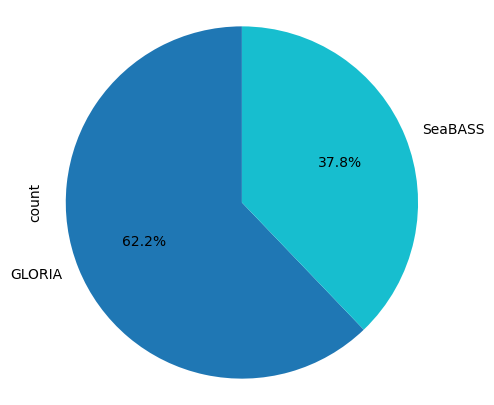

In [4]:
category_counts = rrs['source'].value_counts() 
plt.figure(figsize=(5, 5)) # Optional: set the figure size
category_counts.plot.pie(autopct='%1.1f%%', startangle=90, cmap='tab10')
plt.axis('equal') 
plt.show()

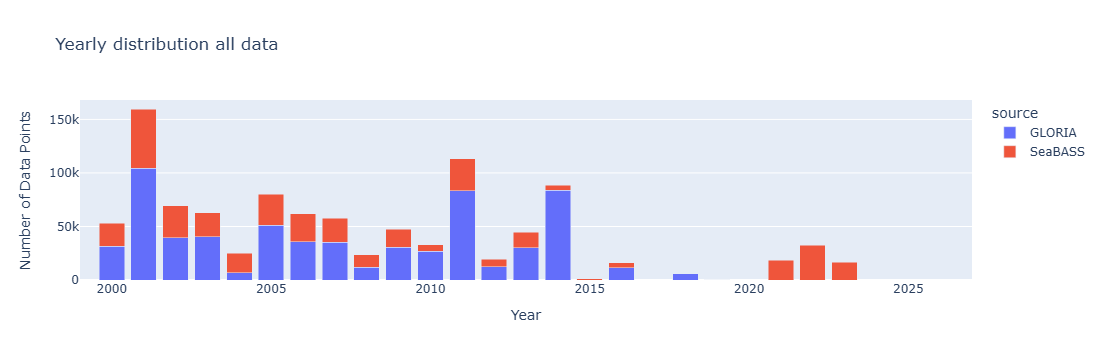

In [5]:
year_test=rrs.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year', 'source']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped, x='year', y='DataPoints', color='source', title='Yearly distribution all data',
    labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

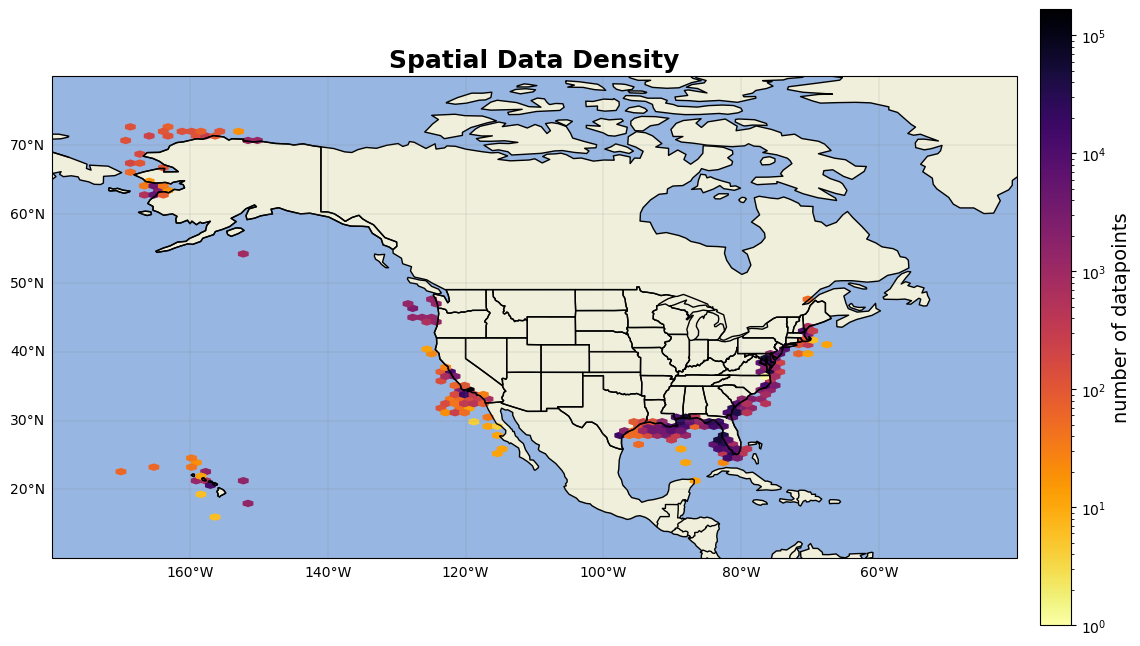

In [7]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(rrs.lon, rrs.lat, gridsize=75, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('number of datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()